In [ ]:
import pandas as pd

df = pd.read_csv("churn_bigml_80.csv")

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
df.shape

(2666, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [ ]:
df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [ ]:
df.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')

In [ ]:
df["Churn"].value_counts()

,count
Churn,
False,2278
True,388


In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
False,85.446362
True,14.553638


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [ ]:
X.head()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,...,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,International plan_Yes,Voice mail plan_Yes
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,...,False,False,False,False,False,False,False,False,False,True
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,...,False,False,False,False,False,False,False,False,False,True
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,...,False,False,False,False,False,False,False,False,False,False
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,...,False,False,False,False,False,False,False,False,True,False
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
X.shape

(2666, 68)

In [ ]:
y = y.map({"No": 0, "Yes": 1})

In [ ]:
y.value_counts()

,count
Churn,


In [ ]:
from sklearn.model_selection import train_test_split

# Re-initialize y from the original DataFrame and map it correctly
y = df["Churn"]
y = y.map({False: 0, True: 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
        y,
            test_size=0.2,
                random_state=42,
                    stratify=y
                    )

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.850187265917603
Precision: 0.46875
Recall: 0.19230769230769232
F1 Score: 0.2727272727272727


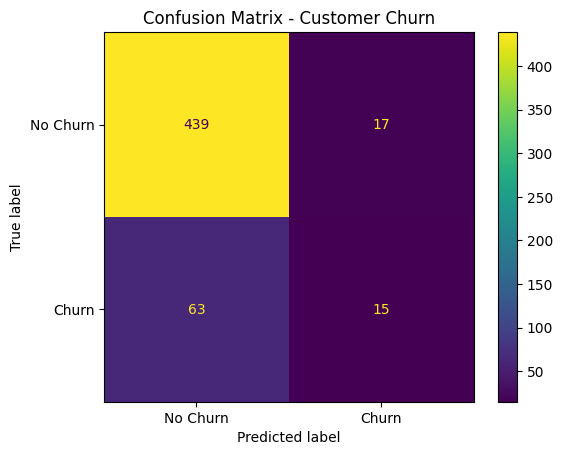

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
        )

disp.plot()

plt.title("Confusion Matrix - Customer Churn")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
        y_pred,
            target_names=["No Churn", "Churn"]
            ))

              precision    recall  f1-score   support

    No Churn       0.87      0.96      0.92       456
       Churn       0.47      0.19      0.27        78

    accuracy                           0.85       534
   macro avg       0.67      0.58      0.59       534
weighted avg       0.82      0.85      0.82       534



In [ ]:
feature_importance = pd.DataFrame({
      "Feature": X.columns,
          "Coefficient": model.coef_[0]
          })

feature_importance["Absolute_Coefficient"] = (
              feature_importance["Coefficient"].abs()
              )

feature_importance = feature_importance.sort_values(
                  "Absolute_Coefficient",
                      ascending=False
                      )

feature_importance.head()


,Feature,Coefficient,Absolute_Coefficient
66,International plan_Yes,2.111557,2.111557
58,State_TX,1.295212,1.295212
60,State_VA,-0.957666,0.957666
54,State_RI,-0.906687,0.906687
46,State_NJ,0.875653,0.875653


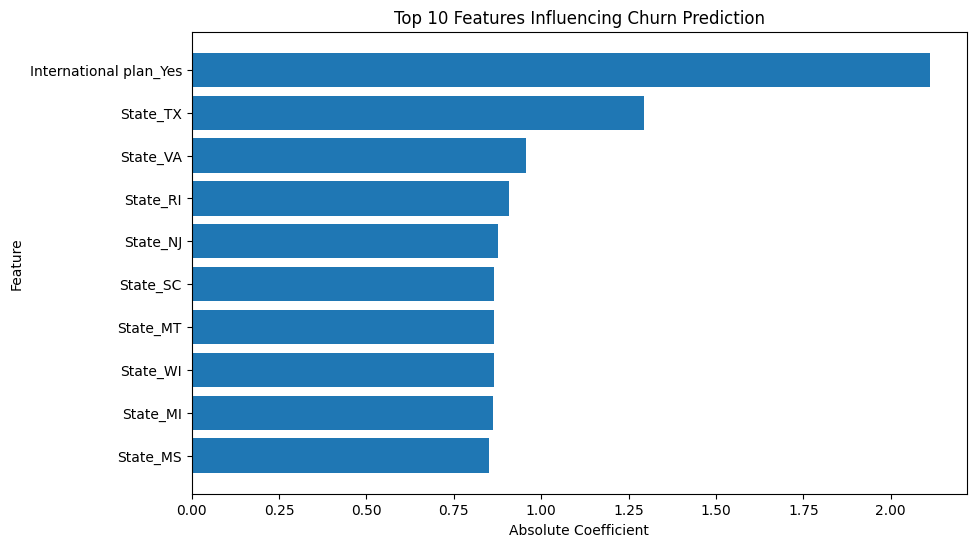

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
        top_features["Absolute_Coefficient"]
        )

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Churn Prediction")

plt.gca().invert_yaxis()
plt.show()